In [12]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# SSL / proxy setup for corporate network + quiet health check
import os
from pathlib import Path
import requests
from dotenv import load_dotenv

load_dotenv()

candidate_paths = [
    os.getenv("CORP_CA_BUNDLE"),
    os.getenv("REQUESTS_CA_BUNDLE"),
    os.getenv("SSL_CERT_FILE"),
    "/etc/ssl/certs/ca-certificates.crt",
    "/usr/lib/ssl/cert.pem",
]

selected_bundle = next(
    (path for path in candidate_paths if path and Path(path).exists()),
    None,
 )

if selected_bundle:
    os.environ["REQUESTS_CA_BUNDLE"] = selected_bundle
    os.environ["SSL_CERT_FILE"] = selected_bundle

diagnostics = []

if not selected_bundle:
    diagnostics.append(
        "No CA bundle found from known paths. Set CORP_CA_BUNDLE in .env."
    )

if not os.getenv("http_proxy") and not os.getenv("https_proxy"):
    diagnostics.append(
        "No proxy env detected. If required in your network, set http_proxy/https_proxy in .env."
    )

try:
    requests.get("https://api.tavily.com", timeout=10)
except requests.exceptions.SSLError as exc:
    diagnostics.append(
        "TLS handshake failed. Export corporate root cert to PEM and set CORP_CA_BUNDLE in .env."
    )
    diagnostics.append(f"SSL error: {exc}")
except Exception as exc:
    diagnostics.append(
        f"Connectivity check failed with {type(exc).__name__}: {exc}"
    )

if diagnostics:
    print("[SSL Check] Action needed:")
    for line in diagnostics:
        print(f"- {line}")

# Research Agent 

*The goal of research is to gather the context requested by the research brief.*

Here is our overall research flow:

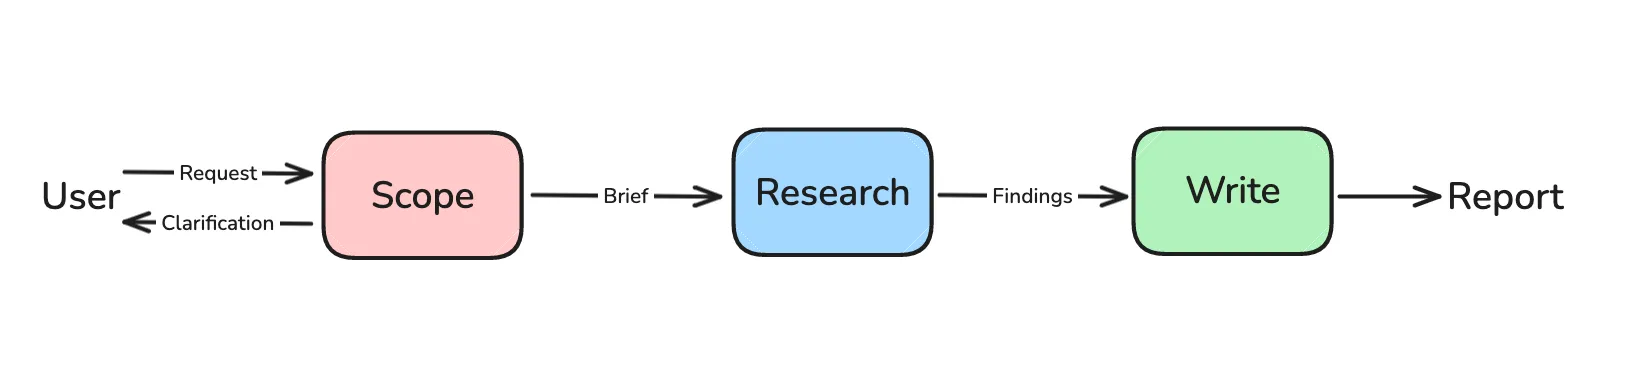

Research is an open‑ended task. The best strategy to answer a user request can't be easily known in advance. 

Requests can require different research strategies and varying levels of search depth. Consider this request:

> *"Compare these two products"*

Comparisons typically benefit from search on each product, followed by a synthesis step to compare them. Now, consider this one:

> *"Give me the top candidates for my job posting"*

Listing and ranking requests typically require open-ended search, followed by a synthesis and ranking.
 
[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) are well suited to research because they can flexibly apply different strategies, using intermediate results to guide their exploration.

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

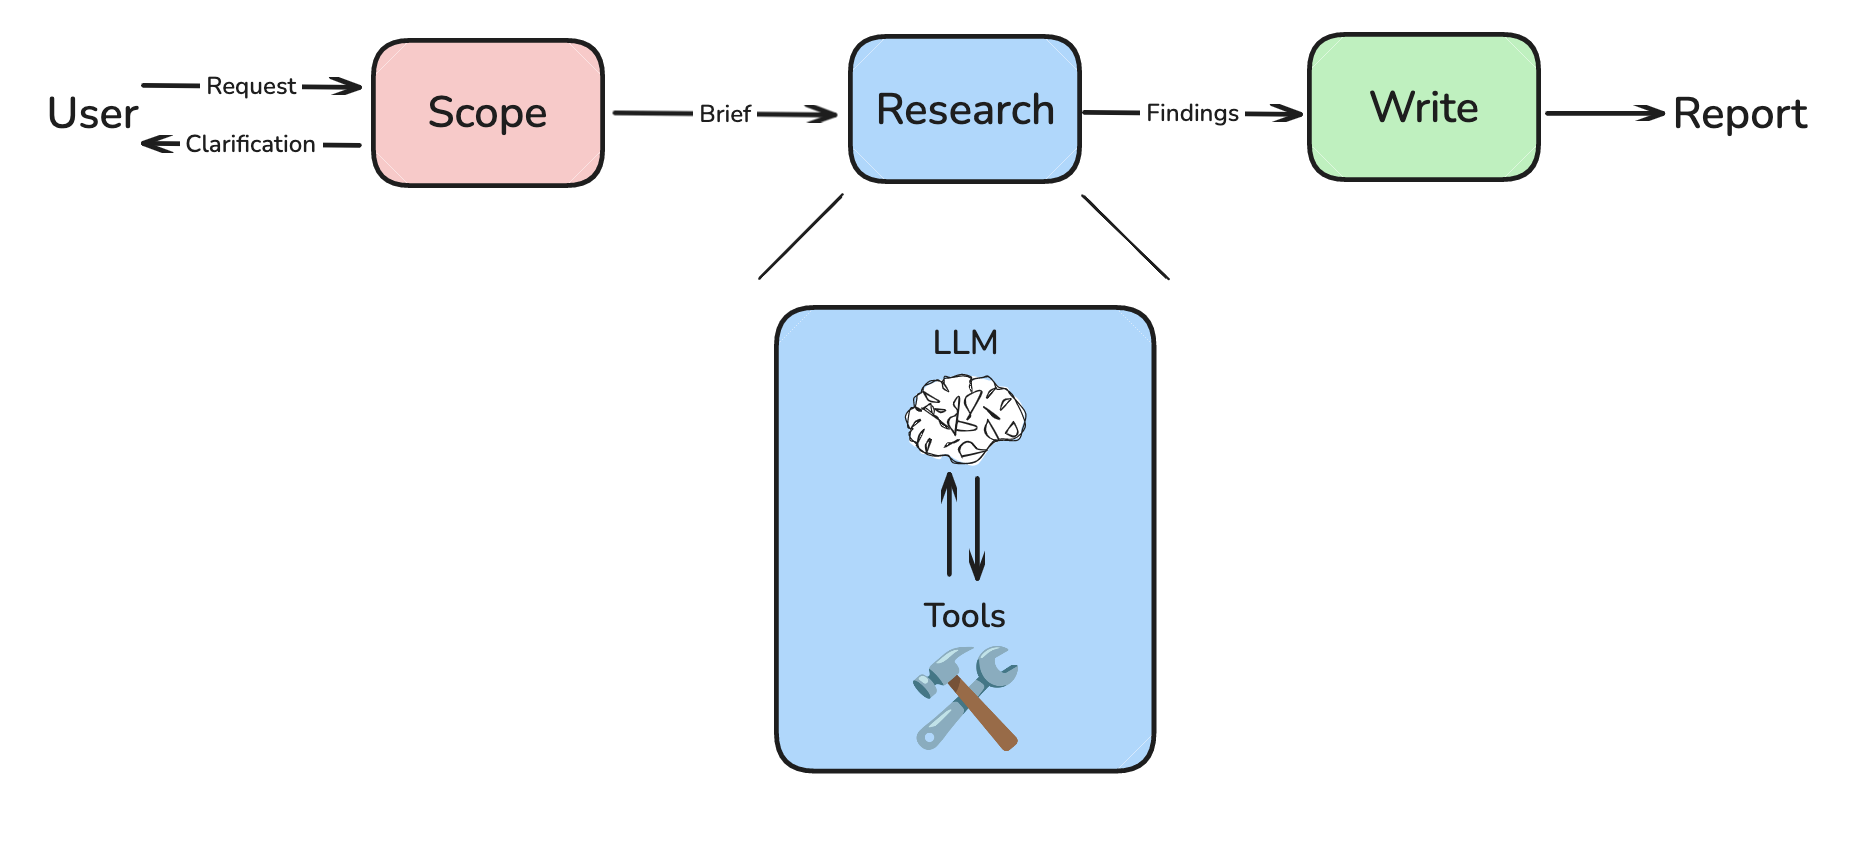

### Prompt

First, we'll define a prompt that instructs our agent to use available search tools. 

To prevent excessive tool calls and maintain research focus, we use [a few prompting techniques for agents](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA):

#### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Start with broader searches** - Use broad, comprehensive queries first
- **After each search, pause and assess** - Do I have enough to answer? What's still missing?
- **Execute narrower searches as you gather information** - Fill in the gaps.

#### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Stop when you can answer confidently** - Don't keep searching for perfection.
- **Give it budgets** - Use 2-3 search tool calls for simple queries. Use up to 5 for complex queries.
- **Limit** - Always stop after 5 search tool calls if you cannot find the right source(s).

#### 3. Show your thinking
After each search tool calling, use [`think_tool` to analyze the results](https://www.anthropic.com/engineering/claude-think-tool):
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

#### Results
These techniques transform problematic research behavior like:
```
"best coffee shops SF" → "Saint Frank Coffee details" → "Sightglass Coffee details" → "Ritual Coffee details" → etc. (20+ searches)
```

Into efficient patterns like:
```
"best coffee shops SF" → ThinkTool(analyze results) → "SF specialty coffee quality ratings" → ThinkTool(assess completeness) → provide answer (3-5 searches total)
```

The key insight: **Think like a human researcher with limited time** - this prevents the "spin-out problem" where agents continue searching indefinitely.

In [14]:
from utils import show_prompt
from deep_research_from_scratch.prompts import research_agent_prompt
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭──────────────────────── Research Agent Instructions ─────────────────────────╮
│                                                                              │
│  You are a research assistant conducting research on the user's input        │
│  topic. For context, today's date is {date}.                                 │
│                                                                              │
│  <Task>                                                                      │
│  Your job is to use tools to gather information about the user's input       │
│  topic.                                                                      │
│  You can use any of the tools provided to you to find resources that can     │
│  help answer the research question. You can call these tools in series or    │
│  in parallel, your research is conducted in a tool-calling loop.             │
│  </Task>                                                                     │
│                           

### State and Schemas

We'll create the agent state object.


In [15]:
%%writefile ../src/deep_research_from_scratch/state_research.py

"""State Definitions and Pydantic Schemas for Research Agent

This module defines the state objects and structured schemas used for
the research agent workflow, including researcher state management and output schemas.
"""

import operator

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from typing_extensions import Annotated, List, Sequence, TypedDict

# ===== IMAGE METADATA SCHEMA =====

class ImageResult(BaseModel):
    """Schema for image metadata collected during research."""

    url: str = Field(description="URL of the image")
    title: str = Field(
        description="Title or alt text of the image", default=""
    )
    source_page: str = Field(
        description="URL of the page where the image was found", default=""
    )
    description: str = Field(
        description="Brief description of the image content", default=""
    )
    local_path: str | None = Field(
        description="Local file path after download", default=None
    )

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """State for the research agent containing message history and research metadata.

    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    images: Annotated[List[ImageResult], operator.add]

class ResearcherOutputState(TypedDict):
    """Output state for the research agent containing final research results.

    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    images: Annotated[List[ImageResult], operator.add]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decisions during scoping phase."""
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")


Overwriting ../src/deep_research_from_scratch/state_research.py


Now, we'll define our research tool.  

#### Tavily SDK Integration

We'll use the [Tavily SDK](https://docs.tavily.com/sdk/python/reference) to perform web searches.
 
Tavily is a search engine optimized for AI applications with a generous free tier, providing:
- Real-time web search results
- Content extraction and summarization
- Domain filtering and result ranking
- Async support for performance

#### Alternative Web Content Sources

While we use Tavily's search API in this tutorial, there are several other excellent options for web content extraction:

- **[Tavily Extract](https://docs.tavily.com/documentation/api-reference/endpoint/extract)**: Tavily's dedicated content extraction endpoint that can extract and clean content from specific URLs without performing searches
- **[Jina Reader](https://jina.ai/reader/)**: A powerful web content extraction service that converts web pages to clean, LLM-friendly text by simply prepending `https://r.jina.ai/` to any URL
- **[Firecrawl](https://www.firecrawl.dev/)**: A comprehensive web scraping platform that converts websites into clean markdown or structured data, with advanced features like JavaScript rendering and sitemap crawling

Each tool has different strengths: Tavily excels at search-first workflows, Jina Reader offers the simplest URL-to-text conversion, and Firecrawl provides the most comprehensive web scraping capabilities for complex sites.

####  LangChain Tools

We'll convert our Tavily search function into a [LangChain tool](https://python.langchain.com/docs/concepts/tools/) using the `@tool` decorator. This enables:
- Automatic schema generation for the LLM
- Integration with LangChain's agent framework
- Standardized tool calling interface
- Type validation and documentation

Note that some of the arguments are noted as [InjectedToolArg](https://python.langchain.com/api_reference/core/tools/langchain_core.tools.base.InjectedToolArg.html). These are not included in the tool schema sent to the LLM, and instead are injected during execution. This gives us the flexibility to inject values at runtime, but does not burden the language model with the responsibility of managing these arguments.

In [16]:
%%writefile ../src/deep_research_from_scratch/utils.py

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

import contextvars
import json
import logging
import os
from datetime import datetime
from functools import wraps
from pathlib import Path
from urllib.parse import urlparse

import requests
import urllib3
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import InjectedToolArg, tool
from tavily import TavilyClient
from typing_extensions import Annotated, List, Literal

from deep_research_from_scratch.Helper import GenAIToken
from deep_research_from_scratch.prompts import summarize_webpage_prompt
from deep_research_from_scratch.state_research import ImageResult, Summary

load_dotenv()
logger = logging.getLogger(__name__)

# ===== SSL CONFIGURATION =====
# Set DISABLE_SSL_VERIFY=true in .env to skip certificate verification when
# operating behind a corporate proxy with self-signed certificates.
if os.getenv("DISABLE_SSL_VERIFY", "").lower() in ("1", "true", "yes"):
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
    _original_requests_post = requests.post

    @wraps(_original_requests_post)
    def _unverified_post(*args, **kwargs):
        kwargs.setdefault("verify", False)
        return _original_requests_post(*args, **kwargs)

    requests.post = _unverified_post

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

_DEFAULT_SUMMARIZATION_MODEL = "azure_openai:gpt-4.1"
_runtime_config: contextvars.ContextVar[dict] = contextvars.ContextVar(
    "runtime_config",
    default={},
)


def set_runtime_config(configurable: dict | None) -> None:
    """Store runtime model overrides for tool-side model resolution."""
    _runtime_config.set(dict(configurable or {}))


def get_runtime_config() -> dict:
    """Return the current runtime model overrides for tool-side helpers."""
    return dict(_runtime_config.get())


_last_search_images: contextvars.ContextVar[list[ImageResult]] = (
    contextvars.ContextVar("last_search_images", default=[])
)


def get_last_search_images() -> list[ImageResult]:
    """Retrieve images extracted from the most recent search call.

    Used by tool_node to pass image metadata into the agent state
    without changing the tool's string return interface.
    """
    return list(_last_search_images.get())


def _build_summarization_model(
    model_id: str | None = None,
    temperature: float = 0.0,
):
    """Build the summarization model with a fresh GenAI token.

    Fallback order is:
    1. Explicit ``model_id`` argument
    2. Runtime ``summarization_model`` override
    3. Runtime ``research_model`` override
    4. Default summarization model
    """
    runtime_config = get_runtime_config()
    resolved_model_id = (
        model_id
        or runtime_config.get("summarization_model")
        or runtime_config.get("research_model")
        or _DEFAULT_SUMMARIZATION_MODEL
    )
    deployment = resolved_model_id.split(":")[-1]
    return init_chat_model(
        model=resolved_model_id,
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=deployment,
        api_key=GenAIToken().token(),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        default_headers={
            "project-name": os.getenv("HEADERS_PROJECT_NAME"),
            "userid": os.getenv("HEADERS_USERID"),
        },
        temperature=temperature,
    )


tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

def tavily_search_multiple(
    search_queries: List[str],
    max_results: int = 3,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = True,
    include_images: bool = True,
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content
        include_images: Whether to include image URLs in results

    Returns:
        List of search result dictionaries
    """
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic,
            include_images=include_images,
        )
        search_docs.append(result)

    return search_docs


def extract_images_from_search_results(
    search_results: List[dict],
) -> list[ImageResult]:
    """Extract deduplicated image metadata from Tavily search responses.

    Handles both plain URL strings and dict-format image entries
    (when Tavily returns descriptions). Populates ``title`` from dict
    entries when available; ``source_page`` is left empty because the
    Tavily API does not attribute images to specific result pages.

    Args:
        search_results: List of raw Tavily search response dicts

    Returns:
        Deduplicated list of ImageResult objects
    """
    seen_urls: set[str] = set()
    images: list[ImageResult] = []

    for response in search_results:
        for img in response.get("images", []):
            if isinstance(img, str):
                url, description, title = img, "", ""
            elif isinstance(img, dict):
                url = img.get("url", "")
                description = img.get("description", "")
                title = img.get("title", "")
            else:
                continue

            if url and url not in seen_urls:
                seen_urls.add(url)
                images.append(
                    ImageResult(
                        url=url,
                        description=description,
                        title=title,
                    )
                )

    return images

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.

    Args:
        webpage_content: Raw webpage content to summarize

    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Rebuild the model for each call so expired GenAI tokens are refreshed.
        structured_model = _build_summarization_model().with_structured_output(Summary)

        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content,
                date=get_today_str()
            ))
        ])

        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )

        return formatted_summary

    except Exception as e:
        logger.warning("Failed to summarize webpage: %s", e)
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.

    Args:
        search_results: List of search result dictionaries

    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}

    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result

    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.

    Args:
        unique_results: Dictionary of unique search results

    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}

    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])

        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }

    return summarized_results

def format_search_output(
    summarized_results: dict,
    images: list[ImageResult] | None = None,
) -> str:
    """Format search results into a well-structured string output.

    Args:
        summarized_results: Dictionary of processed results
        images: Optional list of image metadata to append

    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."

    formatted_output = "Search results: \n\n"

    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"

    if images:
        formatted_output += "\n\n--- IMAGES FOUND ---\n"
        for i, img in enumerate(images, 1):
            formatted_output += f"\n[Image {i}]: {img.url}"
            if img.description:
                formatted_output += f"\n  Description: {img.description}"
            formatted_output += "\n"

    return formatted_output

# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
        include_images=True,
    )

    # Extract image metadata and store for retrieval by tool_node
    images = extract_images_from_search_results(search_results)
    _last_search_images.set(images)

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption (includes images section)
    return format_search_output(summarized_results, images=images)

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"


# ===== IMAGE DOWNLOAD =====

def download_images(
    images: list[ImageResult],
    output_dir: str | Path,
    timeout: int = 5,
) -> list[ImageResult]:
    """Download images to local disk with best-effort error handling.

    Each image is downloaded individually with a timeout. Failures are
    logged but do not prevent other images from being downloaded.
    A metadata JSON file is written alongside the downloaded images.

    Args:
        images: List of ImageResult objects to download
        output_dir: Directory to save downloaded images
        timeout: Per-image download timeout in seconds

    Returns:
        Updated list of ImageResult objects with local_path populated
        for successfully downloaded images
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    verify_ssl = os.getenv("DISABLE_SSL_VERIFY", "").lower() not in (
        "1", "true", "yes",
    )

    _VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".webp", ".svg"}
    _CONTENT_TYPE_MAP = {
        "png": ".png",
        "gif": ".gif",
        "webp": ".webp",
        "svg": ".svg",
        "jpeg": ".jpg",
        "jpg": ".jpg",
    }

    updated: list[ImageResult] = []

    for idx, img in enumerate(images):
        try:
            resp = requests.get(img.url, timeout=timeout, verify=verify_ssl)
            resp.raise_for_status()

            # Derive filename from URL path
            parsed = urlparse(img.url)
            filename = Path(parsed.path).name or ""
            suffix = Path(filename).suffix.lower() if filename else ""

            if suffix not in _VALID_EXTENSIONS:
                # Infer extension from Content-Type header
                content_type = resp.headers.get("content-type", "")
                ext = None
                for key, val in _CONTENT_TYPE_MAP.items():
                    if key in content_type:
                        ext = val
                        break
                if ext is None:
                    logger.warning(
                        "Skipping image with unsupported format: %s "
                        "(content-type: %s)",
                        img.url,
                        content_type,
                    )
                    updated.append(img)
                    continue
                filename = f"image_{idx:03d}{ext}"
            else:
                # Prefix index to avoid filename collisions across domains
                stem = Path(filename).stem
                filename = f"{idx:03d}_{stem}{suffix}"

            filepath = output_path / filename
            filepath.write_bytes(resp.content)
            updated.append(img.model_copy(update={"local_path": str(filepath)}))
            logger.info("Downloaded image: %s -> %s", img.url, filepath)

        except Exception as e:
            logger.warning("Failed to download image %s: %s", img.url, e)
            updated.append(img)  # keep original without local_path

    # Persist structured metadata alongside downloaded images
    metadata_path = output_path / "images_metadata.json"
    metadata = [i.model_dump() for i in updated]
    metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False))

    return updated


Overwriting ../src/deep_research_from_scratch/utils.py


### Research Agent

#### Overview

Our research agent perform iterative tool-calling to search for information. 

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

#### Context Engineering Strategy

We apply **context engineering** in two places following the principles outlined in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/):

#### 1. Webpage Content Summarization
Raw search results often contain excessive noise (navigation, ads, boilerplate content). Our `summarize_webpage_content()` function:
- Uses structured output to extract key information and relevant excerpts
- Filters out irrelevant content while preserving factual details
- Compresses lengthy articles into focused summaries
- Maintains source attribution for credibility

#### 2. Research Result Compression  
As the agent performs multiple searches, the conversation context grows rapidly. Our `compress_research()` function:
- Synthesizes findings from multiple tool calls into cohesive insights
- Extracts raw notes for detailed analysis while maintaining compressed summaries
- Reduces token usage for subsequent LLM calls
- Preserves essential information for report writing

This dual-layer context engineering allows the agent to process extensive information efficiently while maintaining high-quality research output.

#### 3. Performing Careful Compression
[Compression](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) [is risky](https://cognition.ai/blog/dont-build-multi-agents)! We need to be very careful about loosing valuable information. We'll use an LLM for compression with instructions in a system prompt that comes before a potentially long, token-heavy trajectory of multiple tool calls. The long context can cause the compression LLM [to loose sight of the task instructions](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), leading to generic summaries that loose information. So, we reinforce the compression task by adding a `compress_research_human_message` that:
- Explicitly restates the original research topic at compression time
- Reminds the model to preserve ALL information relevant to the specific question
- Emphasizes that comprehensive findings are critical for final report generation
- Prevents task drift during the compression phase

#### 4. Output Token Management
Research compression can generate long outputs. We need to sure that they do not exceed model token limits, which can cause truncated responses that cut off mid-sentence (as seen with "**Sextant Coffee Ro" being cut off). As an example, [GPT-4.1 has output limit of up to 33k tokens](https://openai.com/index/gpt-4-1/) and [Claude4 sonnet supports 64k](https://www.anthropic.com/claude/sonnet). 

Model SDKs / LangChain integrations may cap this (e.g., [to `1024` tokens in the case of Claude](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)). Simply ensure that max tokens is set to ensure complete output. This prevents incomplete compression outputs and ensures full research findings are preserved. Test compression quality vs latency for different models. For example: 

* Claude4-Sonnet 99s latency for compression ([trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r))
* GPT-4.1 38s latency for compression ([trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r))

In [17]:
%%writefile ../src/deep_research_from_scratch/research_agent.py

"""Research Agent Implementation.

This module implements a research agent that can perform iterative web searches
and synthesis to answer complex research questions.
"""

import os

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    ToolMessage,
    filter_messages,
)
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, StateGraph
from typing_extensions import Literal

from deep_research_from_scratch.Helper import GenAIToken
from deep_research_from_scratch.prompts import (
    compress_research_human_message,
    compress_research_system_prompt,
    research_agent_prompt,
)
from deep_research_from_scratch.state_research import (
    ResearcherOutputState,
    ResearcherState,
)
from deep_research_from_scratch.utils import (
    get_last_search_images,
    get_today_str,
    set_runtime_config,
    tavily_search,
    think_tool,
)

load_dotenv()

# ===== CONFIGURATION =====

# Model role defaults
_DEFAULT_RESEARCH_MODEL = "azure_openai:GPT-54-2026-03-05"
_DEFAULT_SUMMARIZATION_MODEL = "azure_openai:GPT-54-2026-03-05"  # used by tool-side webpage summarization when configured
_DEFAULT_COMPRESS_MODEL = "azure_openai:GPT-54-2026-03-05"

# Tools are module-level (no model dependency)
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}


def _build_model(model_id: str, **kwargs):
    """Build an Azure OpenAI model instance from a model identifier string.

    Extracts the deployment name from the model identifier using the
    convention that model name equals deployment name (e.g.,
    "azure_openai:gpt-4.1" -> deployment "gpt-4.1").
    """
    deployment = model_id.split(":")[-1]
    return init_chat_model(
        model=model_id,
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=deployment,
        api_key=GenAIToken().token(),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        default_headers={
            "project-name": os.getenv("HEADERS_PROJECT_NAME"),
            "userid": os.getenv("HEADERS_USERID"),
        },
        **kwargs,
    )


# ===== AGENT NODES =====

def llm_call(state: ResearcherState, config: RunnableConfig):
    """Analyze current state and decide on next actions.

    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information

    Model is controlled by config["configurable"]["research_model"]
    (default: "azure_openai:gpt-4.1").

    Returns updated state with the model's response.
    """
    configurable = config.get("configurable", {})
    set_runtime_config(configurable)
    model = _build_model(
        configurable.get("research_model", _DEFAULT_RESEARCH_MODEL),
        temperature=0.0,
    )
    model_with_tools = model.bind_tools(tools)

    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }


def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.

    Executes all tool calls from the previous LLM responses.
    After each tavily_search call, captures image metadata via
    contextvars and deduplicates against already-collected images.
    Returns updated state with tool execution results and new images.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls

    observations = []
    new_images = []
    seen_urls = {img.url for img in state.get("images", [])}

    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
        if tool_call["name"] == "tavily_search":
            for img in get_last_search_images():
                if img.url not in seen_urls:
                    seen_urls.add(img.url)
                    new_images.append(img)

    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]

    return {"researcher_messages": tool_outputs, "images": new_images}


def compress_research(state: ResearcherState, config: RunnableConfig) -> dict:
    """Compress research findings into a concise summary.

    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.

    Model is controlled by config["configurable"]["compress_model"]
    (default: "azure_openai:gpt-4.1").
    """
    configurable = config.get("configurable", {})
    set_runtime_config(configurable)
    compress_model = _build_model(
        configurable.get("compress_model", _DEFAULT_COMPRESS_MODEL),
        temperature=0.0,
        max_tokens=16384,
    )

    system_message = compress_research_system_prompt.format(date=get_today_str())

    # Append structured image metadata so references survive compression
    human_content = compress_research_human_message
    images = state.get("images", [])
    if images:
        image_lines = [
            f"- {img.url}"
            + (f" — {img.description}" if img.description else "")
            for img in images
        ]
        human_content += (
            "\n\n--- IMAGES COLLECTED DURING RESEARCH ---\n"
            + "\n".join(image_lines)
            + "\nPreserve references to relevant images in your "
            "compressed output."
        )

    messages = (
        [SystemMessage(content=system_message)]
        + state.get("researcher_messages", [])
        + [HumanMessage(content=human_content)]
    )
    response = compress_model.invoke(messages)

    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"],
            include_types=["tool", "ai"]
        )
    ]

    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }


# ===== ROUTING LOGIC =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.

    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.

    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tool_node"
    return "compress_research"


# ===== GRAPH CONSTRUCTION =====

agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node",
        "compress_research": "compress_research",
    },
)
agent_builder.add_edge("tool_node", "llm_call")
agent_builder.add_edge("compress_research", END)

researcher_agent = agent_builder.compile()


Overwriting ../src/deep_research_from_scratch/research_agent.py


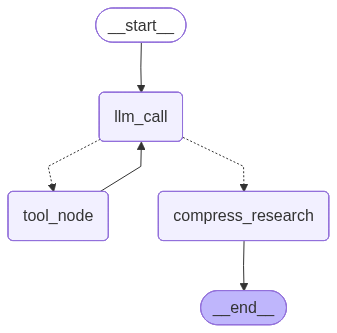

In [18]:
import base64
import httpx
from IPython.display import Image, display
from deep_research_from_scratch.research_agent import researcher_agent

# Show the agent
mermaid = researcher_agent.get_graph(xray=True).draw_mermaid()
encoded = base64.urlsafe_b64encode(mermaid.encode("utf-8")).decode("ascii")
image_url = f"https://mermaid.ink/img/{encoded}?type=png&bgColor=%21white"

with httpx.Client(timeout=20.0, verify=False, trust_env=True) as client:
    response = client.get(image_url)
    response.raise_for_status()
    png_bytes = response.content

display(Image(png_bytes))

In [9]:
# Run the agent
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """What are the latest trend in juice design including color, decorations and 纹理感 for premium facial serum in China from 2026?请给出参考的图片"""

result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['researcher_messages'])

Failed to summarize webpage: Error code: 422 - {'detail': [{'type': 'enum', 'loc': ['path', 'deployment_id'], 'msg': "Input should be 'GPT-5-2025-08-07', 'GPT-5-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-MINI-2025-08-07', 'GPT-5-MINI-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-MINI-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-NANO-2025-08-07', 'GPT-5-NANO-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-NANO-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-CHAT-2025-08-07', 'GPT-51-2025-11-13', 'GPT-51-2025-11-13-LOW-CONTENT-FILTERS', 'GPT-51-2025-11-13-NO-CONTENT-FILTERS', 'GPT-52-2025-12-11', 'GPT-52-2025-12-11-LOW-CONTENT-FILTERS', 'GPT-52-2025-12-11-NO-CONTENT-FILTERS', 'GPT-53-CHAT-2026-03-03', 'GPT-53-CHAT-2026-03-03-LOW-CONTENT-FILTERS', 'GPT-53-CHAT-2026-03-03-NO-CONTENT-FILTERS', 'GPT-54-2026-03-05', 'GPT-54-2026-03-05-LOW-CONTENT-FILTERS', 'GPT-54-2026-03-05-NO-CONTENT-FILTERS', 'GPT-54-PRO-2026-03-05', 'GPT-54-PRO-2026-03-05-LOW-CONTENT-FILTERS', 'GPT-54-PRO-2026-03-0

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What are the latest trend in juice design including color, decorations and 纹理感 for premium facial serum in   │
│ China from 2026?请给出参考的图片.                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "China 2026 premium facial serum packaging trends color decoration texture juice design cosmetic     │
│ bottle trends images"                                                                                           │
│ }                                                                                                               │
│    ID: call_lTE4U849CqSMHbGjLQzq7qxG                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "2026 \u4e2d\u56fd \u9ad8\u7aef \u7cbe\u534e \u6db2 \u89c6\u89c9 \u8d8b\u52bf \u5305\u88c5           │
│ \u8272\u5f69 \u88c5\u9970 \u7eb9\u7406\u611f \u56fe\u7247"                                                      │
│ }                                                                                                               │
│    ID: call_tLQm0PrLtx33oXpQBVJrl4k0                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "beauty packaging trend forecast 2026 serum bottle CMF texture premium China images"                 │
│ }                                                                                                               │
│    ID: call_INJP4wLI0zfGKOxRjC8VM9i7                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 2026 Packaging Trends in Premium Cosmetics - RAFESA ---                                           │
│ URL: https://rafesa.com/en/2026-packaging-trends-in-premium-cosmetics/                                          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ [Skip to content](#content)                                                                                     │
│                                                                                                                 │
│ +34 93 460 88 00 | info@rafesa.com                                                                              │
│                                                                                                                 │
│ ![Logo RAFESA packaging](https://rafesa.com/wp-content/uploads/2022/04/logtipo-rafesa.png)                      │
│                                                                                                                 │
│ # 2026 Packaging Trends in Premium Cosmetics                                                                    │
│                                                                                                                 │
│ ![Tendencias 2026 en packaging para cosmética                                                                   │
│ premium](https://rafesa.com/wp-content/uploads/2026/01/Bodegon-tarros-llenos-02.jpg)                            │
│                                                                                                                 │
│ If there is one thing that has clearly changed in premium cosmetic packaging over recent years, it is the very  │
│ definition of “luxury.” Today’s consumer still expects a strong sensory experience and aesthetic coherence—but  │
│ now also demands reduced environmental impact, transparency, and real usability. In 2026, this tension between  │
│ desirability and responsibility is no longer a theoretical discussion: it becomes a decisive factor in          │
│ purchasing decisions, brand reputation, and—more and more—regulatory compliance.                                │
│                                                                                                                 │
│ In this article, we bring together some of the key 2026 trends in premium cosmetic packaging and, above all,    │
│ what they mean for marketing, R&D, and...                                                                       │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: What trends are shaping skincare bottle design in 2026? – APG Packaging ---                       │
│ URL: https://apackaginggroup.com/blogs/news/what-trends-are-shaping-skincare-bottle-design-in-2026              │
│                                                        

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 24 款令人惊叹的极简主义护肤品包装设计 - UKPACK ---                                                │
│ URL:                                                                                                            │
│ https://www.ukpackchina.com/zh-CN/24-%E6%AC%BE%E4%BB%A4%E4%BA%BA%E6%83%8A%E5%8F%B9%E7%9A%84%E6%9E%81%E7%AE%80%E │
│ 6%8A%A4%E8%82%A4%E5%93%81%E5%8C%85%E8%A3%85%E8%AE%BE%E8%AE%A1/                                                  │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![...](data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAA+gAAAPoCAYAAABNo9TkAAAACXBIWXMAAA7EAAAOxAGVKw4bAAAPPElEQV │
│ R42u3BAQ0AAADCoPdPbQ43oAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA │
│ AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA │
│ AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA │
│ AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA │
│ AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA │
│ AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA │
│ AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA │
│ AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA │
│ A...                                                                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Pentawards发布2025-2026包装趋势！包装设计的10个“破界” 方向 ---                                    │
│ URL: https://zhuanlan.zhihu.com/p/1980361669218681389                                                           │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 无障碍设计、多巴胺色彩、游戏化的开箱体验、收藏级包装容器……2026年的包装趋势，直观呈现了该年度包装设计的丰富形态  │
│ 、长远构想与创意亮点。本篇文章，我们                                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 3: 从佛山看趋势：今年爆款包装都在这几个细节上 ---    

...

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Instagram ---                                                                                     │
│ URL: https://www.instagram.com/p/DWX09_ElKMO/                                                                   │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![](data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAKAAAACgCAYAAACLz2ctAAAtXklEQVR4AezBAQ0AAAjAoNu/tDl0QAAAAAAAA │
│ G9NRy179gDrX9NdcfyzZ8793b9r27Zt2wqqoHYb1rYdt1Hj1AhqI6jdPrafizO7uHOSnfMi+uvFTlZm73XO9TdrZnK/TB6/Ctef5jqudm4MbgTX │
│ BofGUXAYHJaLvq/GUee4GR2tGz2tndaa80a2hWhAdCPCiAA0dBmBBQ1bH4BONqFJi8ggm6FrGWRnXKwxmrHS1kWsYYyDOBucdLk27Sycnod2cix │
│ Ohzw7Fs8NnljFk8PZ01fFs087fRzPegmt+HP3uNvrF7325eD1lu6t1/SW2bxWX71x8iqRDskRjoNlqk9FoyW9yUjZQvYwgmxdIqMRzRoNNuiEjm │
│ YIIqQmNQQaltJvft/gFLnNDX3OIbLJ7FKIPBIjZAbTjzUYTeairawjGOToYm2chHG6cIa1y8eSe7r492Y8EM7/7Ez7rzf1mg8j3eUVKd1N9ZVXv │
│ UY786qteUfpnYKPkN5QuhaJokgCEEUNCbM34QlDQxhCCpu/gjb9xtTQUOHr6ucMCzbfXKN4Md+pMIbQ6rtzbnLO1Ln21QspdjPDBaT53138NeN3 │
│ mvO/Pji+7xW95n04eTmAu/o8Lr3qVW++nnmj1ny08B6R3ly6DJEYhLnu4bPv9zCOCVAW+NjgaxID6QghN1AnHEOvMBTgluLt4eo28KI+n37Od7M │
│ AOHQNSQGvzb4CGGWtgDLUPlg79zTrn5G/162//4z1P/Cwu6DiHv/gTtYPXXnzj8nwYdL7S6/b0qtFIIkJm6TC15JaHQqE6h+spF2Xcs6b39VkTI │
│ tkex/toi/gbT52oDW0CZitl5svsGy9nE5qWMQOMKImq6SAW1O5wvjCNbbPfTqs/975S/JXbzj/VTxyhxPw79yJ+porb/lOwee15qMNryNdikQWg │
│ C...                                                                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Instagram ---                                                                                     │
│ URL: https://www.instagram.com/p/DWf6T_YFENH/                                                                   │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![](data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAKAAAACgCAYAAACLz2ctAAAtXklEQVR4AezBAQ0AAAjAoNu/tDl0QAAAAAAAA │
│ G9NRy179gDrX9NdcfyzZ8793b9r27Zt2wqqoHYb1rYdt1Hj1AhqI6jdPrafizO7uHOSnfMi+uvFTlZm73XO9TdrZnK/TB6/Ctef5jqudm4MbgTX │
│ BofGUXAYHJaLvq/GUee4GR2tGz2tndaa80a2hWhAdCPCiAA0dBmBBQ1bH4BONqFJi8ggm6FrGWRnXKwxmrHS1kWsYYyDOBucdLk27Sycnod2cix │
│ Ohzw7Fs8NnljFk8PZ01fFs087fRzPegmt+HP3uNvrF7325eD1lu6t1/SW2bxWX71x8iqRDskRjoNlqk9FoyW9yUjZQvYwgmxdIqMRzRoNNuiEjm │
│ YIIqQmNQQaltJvft/gFLnNDX3OIbLJ7FKIPBIjZAbTjzUYTeairawjGOToYm2chHG6cIa1y8eSe7r492Y8EM7/7Ez7rzf1mg8j3eUVKd1N9ZVXv │
│ UY786qteUfpnYKPkN5QuhaJokgCEEUNCbM34QlDQxhCCpu/gjb9xtTQUOHr6ucMCzbfXKN4Md+pMIbQ6rtzbnLO1Ln21QspdjPDBaT53138NeN3 │
│ mvO/Pji+7xW95n04eTmAu/o8Lr3qVW++nnmj1ny08B6R3ly6DJEYhLnu4bPv9zCOCVAW+NjgaxID6QghN1AnHEOvMBTgluLt4eo28KI+n37Od7M │
│ AOHQNSQGvzb4CGGWtgDLUPlg79zTrn5G/162//4z1P/Cwu6DiHv/gTt

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 2026 Color Trends Set to Dominate Beauty Packaging ---                                            │
│ URL: https://neomirae.com/2026-color-trends-set-to-dominate-beauty-packaging/                                   │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Skip links                                                                                                      │
│                                                                                                                 │
│ * [Skip to primary navigation](#primary-nav)                                                                    │
│ * [Skip to content](#lqd-site-content)                                                                          │
│                                                                                                                 │
│ Instagram   Tiktok   Linkedin-in    [Pinterest](https://pinterest.com/neomirae/)                                │
│                                                                                                                 │
│ Type and hit enter                                                                                              │
│                                                                                                                 │
│ [![Neo                                                                                                          │
│ Mirae](https://sp-ao.shortpixel.ai/client/to_webp,q_glossy,ret_img/https://neomirae.com/wp-content/uploads/2025 │
│ /05/neo-mirae-logo-blue_950x124.png) ![Neo                                                                      │
│ Mirae](data:image/svg+xml,%3Csvg%20xmlns=%22http://www.w3.org/2000/svg%22%20viewBox=%220%200%20210%20140%22%3E% │
│ 3C/svg%3E)](https://neomirae.com/)                                                                              │
│                                                                                                                 │
│ * [ABOUT US](https://neomirae.com/about-us/)                                                                    │
│ * [SERVICE](https://neomirae.com/service/)                                                                      │
│ * [PRODUCTS](https://neomirae.com/products/)                                                                    │
│   + [Skincare](https://neomirae.com/skincare/)                                                                  │
│   + [Makeup](https://neomirae.com/makeup/)                                                                      │
│   + [Optical](https://neomirae.com/optical/)                                                                    │
│   + [Feminine Care](https://neomirae.com/feminine-care/)                                                        │
│ * [BLOG](https://neomirae.com/blog-posts/)                                                                      │
│ * [FAQ](https://neomirae.com/faq/)                                                                              │
│                                                                                                                 │
│ [Contact Us](https://neomirae.com/neomirae-inquiry/)   

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The narrower searches were mixed quality. Useful findings: color direction includes            │
│ translucent/natural amber, milky pearl, and soft gradients from beauty packaging trend sources; China-specific  │
│ macro trend from Jing Daily supports 'proof over price' and quiet luxury/craft-first philosophy, which aligns   │
│ with restrained premium serum aesthetics. Chinese packaging article gives concrete tactile and decoration cues: │
│ matte, spot UV, local cultural textures, simplified info hierarchy. I now have enough to answer with a          │
│ practical trend framework for China 2026 premium facial serum 'juice design' including liquid color, decorative │
│ finishes, and texture feel. For image references, I should provide the directly surfaced URLs that seem most    │
│ relevant and clearly label them as reference images/examples rather than exact trend proof. No more searching   │
│ needed because recent searches are repeating similar signals."                                                  │
│ }                                                                                                               │
│    ID: call_ZTtwK5meuFoTHwUTOB190dzt                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The narrower searches were mixed quality. Useful findings: color direction includes        │
│ translucent/natural amber, milky pearl, and soft gradients from beauty packaging trend sources; China-specific  │
│ macro trend from Jing Daily supports 'proof over price' and quiet luxury/craft-first philosophy, which aligns   │
│ with restrained premium serum aesthetics. Chinese packaging article gives concrete tactile and decoration cues: │
│ matte, spot UV, local cultural textures, simplified info hierarchy. I now have enough to answer with a          │
│ practical trend framework for China 2026 premium facial serum 'juice design' including liquid color, decorative │
│ finishes, and texture feel. For image references, I should provide the directly surfaced URLs that seem most    │
│ relevant and clearly label them as reference images/examples rather than exact trend proof. No more searching   │
│ needed because recent searches are repeating similar signals.                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 可以。下面我按你关心的 **juice design（内料视觉）+ color（色彩）+ decorations（装饰工艺）+                      │
│ 纹理感（触感/视觉纹理）** 来总结 **中国市场 2026 年高端面部精华（premium facial serum）**                       │
│ 的最新方向，并附上可参考的图片链接。                                                                            │
│                                                                                                                 │
│ > 说明：                                                                                                        │
│ > 1) 这里的“juice                                                                                               │
│ design”我理解为**精华液本体的视觉设计**，包括液体颜色、透明度、流动感、悬浮感、珠光感、分层感等。               │
│ > 2) 趋势基于 2026 美妆包装趋势、国内包装趋势文章、中国美妆市场观察，以及高端护肤包装常见 CMF 方向综合归纳。    │
│ > 3) 图片以**趋势参考/视觉参考**为主，适合做 moodboard，不一定全部都是“中国本土品牌已上市精华”。                │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # 一、2026 中国高端精华的核心审美方向：从“贵气感”转向“证据型奢华”                                               │
│                                                                                                                 │
│ 在中国 2026 年高端精华赛道，明显不是以前那种“金色越多越贵”。更强的方向是：                                      │
│                                                                                                                 │
│ - **克制型高级感（quiet luxury）**                                                                              │
│ - **功效可视化（proof-based beauty）**                                                                          │
│ - **触感升级（tactile luxury）**                                                                                │
│ - **自然科技感（bio-tech + natural fusion）**                                                                   │
│ - **东方在地纹理表达**                                                                                          │
│                                                                                                                 │
│ 也就是说，高端精华的设计语言会更像：                                                                            │
│                                                                                                                 │
│ - 颜色不一定浓烈，但要**有层次**                                                                                │
│ - 装饰不一定复杂，但要**精致、可触、可近看**                                                                    │
│ - 液体不一定“很艳”，但要**让人相信它有效、纯净、稳定、贵**                                                      │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # 二、2026 年 premium facial serum 在中国的最新 juice design 趋势                                               │
│                                                                                                                 │
│ ## 1）颜色趋势：从“高饱和贵妇金”转向“低饱和、半透明、功能感色彩”                                                │
│                                                                                                                 │
│ ### A. 微琥珀 / 药感金棕（light amber / biotech amber）                                                         │
│ 这是 2026 非常重要的一类。                                                                                      │
│                                                                                                                 │
│ **适合：**                 

In [10]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

 1 Tavily search query: China 2026 premium facial serum packaging trends color decoration texture juice design     
   cosmetic bottle trends images                                                                                   
 2 Tavily search query: 2026 中国 高端 精华 液 视觉 趋势 包装 色彩 装饰 纹理感 图片                                
 3 Tavily search query: beauty packaging trend forecast 2026 serum bottle CMF texture premium China images         
 4 Tavily search query: 中国 高端 精华 包装 2026 瓶身 纹理 哑光 局部UV 渐变 玻璃 图片                              
 5 Tavily search query: 2026 serum juice color trend skincare China translucent amber pearl milky gradient         
   packaging images                                                                                                

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fully Comprehensive Findings                                                                                       

The gathered research points consistently to a 2026 premium skincare/serum design direction centered on sensory    
experience, tactile cues, minimalism, restrained luxury, and material/finish detail rather than overtly decorative 
luxury. Multiple sources stated that packaging is no longer just a container, but “the first moment of connection,”
and that “the texture of a sachet, the choice of colors, the graphic design, and even the way a pack opens all     
shape perception long before a product is even used.” This makes color, texture, and opening experience directly   
relevant to premium facial serum design [1][2][3][4][5][6][7][8][9].                                               

A recurring 2026 premium cosmetics packaging signal is that the definition of “luxury” has changed. RAFESA stated: 
“Today’s consumer still expects a strong sensory experience and aesthetic coherence—but now also demands reduced   
environmental impact, transparency, and real usability. In 2026, this tension between desirability and             
responsibility is no longer a theoretical discussion: it becomes a decisive factor in purchasing decisions, brand  
reputation, and—more and more—regulatory compliance” [1]. This supports a design direction for premium serums in   
China that is sensorial and elevated but also restrained and usability-led [1].                                    

APG Packaging surfaced as a source explicitly focused on 2026 skincare bottle design, titled “What trends are      
shaping skincare bottle design in 2026?” [2]. Although the search summary did not expose full detailed bullets, the
result itself is directly relevant as a 2026 skincare bottle design trend source [2].                              

Amcor’s “5 Eye-catching trends in beauty packaging” explicitly framed packaging as critical to perception and      
purchase: “In the beauty industry, packaging is far more than a container — it’s the first moment of connection    
between a brand and the customer. The texture of a sachet, the choice of colors, the graphic design, and even the  
way a pack opens all shape perception long before a product is even used. In a sector driven by aesthetics,        
innovation, and emotion, packaging plays a critical role in influencing purchasing decisions and building brand    
loyalty.” Amcor also stated that brands are under increasing pressure to deliver packaging that is “not only       
visually striking but also more sustain...” [3]. This is directly relevant to color, decorations, and texture feel 
in premium serum packaging [3].                                                                                    

MJS Packaging’s “2026 Skincare & Beauty Packaging Trends: Part 1” stated: “Skincare trends are being driven by more
than aesthetics. Consumers are value-conscious, ingredient-savvy, sustainability-aware and in

We can see the trace [here](https://smith.langchain.com/public/30eebc0c-455e-4db7-9665-d367ebd40b4e/r).

### LangGraph Studio

Just as we did before, we can also use LangGraph Studio to visualize the agent. 

This agent has been added to the `langgraph.json` file, so you can select `research_agent` in the dropdown menu:

```
"research_agent_mcp": "./src/deep_research_from_scratch/research_agent.py:agent"
```

Run the following command to start the studio

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

## Eval

Agents use a self-directed trajectory of tool calls to accomplish tasks.

Let's think about the ramifications of a poorly tuned tool-calling loop: 

- Early Termination: The agent decides to stop calling tools when the task is not actually complete. 
- Prolonged Looping: The agent is never satisfied with the state of its information. 

The first failure  mode results in the agent collecting insufficient information. In the deep research context, the answer may end up being too shallow. The second failure mode results in the agent utilizing an excessive number of tokens. In the deep research context, irrelevant information may poison the result.

We tuned our prompt to avoid these problems. But, let's se up a toy eval dataset that allows us to easily test agent decision-making.

In [19]:
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

# Scenario 1: Agent should CONTINUE - has insufficient/irrelevant information + think_tool realizes more research needed
messages_should_continue = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll search for information about top coffee shops in San Francisco focusing on coffee quality.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "coffee shops San Francisco popular locations"
                },
                "id": "call_continue_search_001",
                "type": "tool_call"
            }
        ]
    ),
    # Tavily Search provides generic cafe information - NOT focused on coffee quality
    ToolMessage(
        content="Search results show popular San Francisco cafes: Blue Bottle Coffee has great wifi and ambiance, Philz Coffee is known for custom blends and friendly service, Café Reveille has multiple locations with good pastries and laptop-friendly spaces. Ritual Coffee offers cozy seating and is popular with students.",
        tool_call_id="call_continue_search_001",
    ),
    # Agent uses think_tool to reflect and realizes the search results are insufficient
    AIMessage(
        content="Let me use the think_tool to analyze these search results and determine next steps.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality."
                },
                "id": "call_continue_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response identifies the gap and need for more targeted research
    ToolMessage(
        content="Reflection recorded: Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality.",
        tool_call_id="call_continue_think_001",
    )
]

# Scenario 2: Agent should STOP - has comprehensive coffee quality information + think_tool reflection
messages_should_stop = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll research San Francisco coffee shops specifically focusing on coffee quality assessments and expert reviews.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "best coffee quality San Francisco specialty coffee expert reviews Coffee Review ratings 2024"
                },
                "id": "call_stop_search_001", 
                "type": "tool_call"
            }
        ]
    ),
    # This ToolMessage provides COMPREHENSIVE coffee quality information - sufficient to answer the question
    ToolMessage(
        content="""Coffee quality research for San Francisco reveals top establishments based on expert reviews and specialty coffee credentials:

**Top Quality-Focused Coffee Shops:**
1. **Sightglass Coffee** - Coffee Review score 94/100, known for single-origin beans and precise roasting techniques. Featured in Bon Appétit's "Best Coffee in America" list for exceptional coffee quality.

2. **Saint Frank Coffee** - Ranked #3 coffee shop in America by The Daily Meal based on coffee quality. 4.3/5 Yelp rating with reviews specifically praising "exceptional bean quality" and "perfect extraction."

3. **Ritual Coffee Roasters** - Specialty Coffee Association member, direct trade relationships, consistently rated 4.4/5 on Google with reviews highlighting "superior coffee taste" and "expert barista skills."

4. **Blue Bottle Coffee** - Third-wave coffee pioneer, Coffee Review scores averaging 90+/100, known for rigorous quality control and fresh roasting practices.

5. **Four Barrel Coffee** - Local roaster with Coffee Review scores 88-92/100, praised by industry experts for "exceptional coffee quality" and innovative brewing methods.

**Quality Indicators Found:**
- Coffee Review professional scores (88-94/100 range)
- Specialty Coffee Association certifications
- Direct trade/single-origin sourcing
- Expert recognition from food publications
- Customer reviews specifically mentioning coffee taste and quality

This provides a comprehensive assessment of SF coffee shops based specifically on coffee quality rather than ambiance or service.""",
        tool_call_id="call_stop_search_001",
    ),
    # Agent now uses think_tool to reflect on the search results
    AIMessage(
        content="Let me reflect on the search results using the think_tool to assess whether I have sufficient information.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now."
                },
                "id": "call_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response confirming reflection was recorded
    ToolMessage(
        content="Reflection recorded: Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now.",
        tool_call_id="call_think_001",
    )
]

We'll create a dataset here that has one example that should continue researching, and another example that should have all of the information necessary.

In [20]:
from utils import init_langfuse

langfuse = init_langfuse()

# Create the dataset
dataset_name = "deep_research_agent_termination"
try:
    langfuse.get_dataset(dataset_name)
    print(f'Dataset "{dataset_name}" already exists.')
except Exception:
    langfuse.create_dataset(
        name=dataset_name,
        description="A dataset that evaluates whether a researcher can accurately decide to continue calling tools, or to stop.",
    )
    for item in [
        {
            "input": {"researcher_messages": messages_should_continue},
            "expected_output": {"next_step": "continue"},
        },
        {
            "input": {"researcher_messages": messages_should_stop},
            "expected_output": {"next_step": "stop"},
        },
    ]:
        langfuse.create_dataset_item(
            dataset_name=dataset_name,
            input=item["input"],
            expected_output=item["expected_output"],
        )
    print(f'Created dataset "{dataset_name}" with 2 items.')


Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


AttributeError: 'Langfuse' object has no attribute 'api'

Here, our evaluator is simple, using a hard-coded heuristic to check if the agent correctly continues or stops.

We'll pass in the list of messages above.

We'll assess the decision made by the agent: 

* `stop` - No tool calls means the agent should stop
* `continue` - Tool calls means the agent should continue

We'll then compare this decision to the reference expected decision `next_step`.

In [ ]:
import uuid


def evaluate_next_step(*, output, expected_output, **kwargs):
    """Heuristic evaluator: check if the agent correctly continues or stops."""
    tool_calls = output["researcher_messages"][-1].tool_calls
    made_tool_call = len(tool_calls) > 0
    is_correct = made_tool_call == (expected_output["next_step"] == "continue")
    return {
        "name": "correct_next_step",
        "value": 1.0 if is_correct else 0.0,
        "comment": f"expected={expected_output['next_step']}, tool_calls={len(tool_calls)}",
    }


def target_func(*, item, **kwargs):
    """Run a single LLM call node for evaluation."""
    config = {"configurable": {"thread_id": str(uuid.uuid4())}}
    return researcher_agent.nodes["llm_call"].invoke(
        {"researcher_messages": item.input["researcher_messages"]},
        config=config,
    )


langfuse.run_experiment(
    name=dataset_name,
    run_name="Researcher Iteration",
    data=langfuse.get_dataset(dataset_name).items,
    task=target_func,
    evaluators=[evaluate_next_step],
)


We can see that in one example, the search tool doesn't return enough information, so we submit another search via tool call.

In the other example, we get all three top restaurants back, and so we decide to conclude.

One neat trick here - we were able to test a single node of our graph by calling `agent.nodes["node_name].invoke`